# Individualized weekly retraining — **upweighting** + feature-set / model sweep

Ported from `howdy-server/notebooks/eval_retrain_upweight.ipynb` and broadened the
way this project's `eval_retrain_feature_sets.ipynb` was.

Same question — _does retraining a per-participant model each week beat a single
static model?_ — on the **production** feature stack vendored from
`howdy_lib.features` (`howdy_features.py`). Key production choices, tested here:

- **no HRV** (the production feature set excludes it by construction), and
- per-dyad **upweighting** via a classifier `sample_weight` instead of
  bootstrapping the dyad's history.

Broadened over the research project's axes:

- **both estimators** — XGBoost and L2 logistic regression,
- **all feature-set combinations** — `watch` / `+demographic` / `+medical` / `+both`
  (demographics as defined in this project's `util.py`; HRV excluded),
- results cached as **parquet** (tidy per-prediction rows) and fitted pipelines as
  joblib, so the long training run is never repeated for analysis.

Design (mirrors the source notebook): population/train = **Sham** arm; the
**Active** arm is walked week-by-week. `retrain_dyad` gives each active dyad its own
model, refit on the population + that dyad's accumulated history (its rows
**upweighted** by the number of active dyads); `no_retrain` scores every week with
the single population model. We report **cumulative** AUROC / sensitivity /
specificity (each week pools its predictions with all earlier weeks').

The modeling helpers live in `eval_lib.py`; everything XGBoost-specific is delegated
to the vendored `howdy_features.py`.


## Configuration


In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import pandas as pd

import howdy_features as F  # vendored copy of howdy_lib.features
import eval_lib as E  # the LR/feature-set/upweight/caching extensions
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Tidy per-prediction parquet results (one file per estimator/feature-set/mode).
INTERMEDIATE_DIR = Path("intermediate_data")

# Raw 15-min interval history (the input engineer_features expects) -- the full
# pistachio-1 frame copied from howdy-server; it also carries the demographic cols.
HISTORICAL_DF_PATH = INTERMEDIATE_DIR / "historical/pistachio_1_all_dyads.parquet"

# Fitted pipelines + per-combo FLAML configs (resumable cache).
MODELS_DIR = INTERMEDIATE_DIR / "models/eval_retrain_upweight_models"

RESPONSE_COLUMN = E.RESPONSE_COLUMN  # "tantrum_within_60m"
WEEKS = (0, 20)
ACTIVE_HOURS = (7, 20)
RANDOM_STATE = E.RANDOM_STATE

# FLAML HPO budget. HPO runs ONCE per (estimator, feature set) on the population;
# every weekly per-dyad refit reuses that config and only re-tunes the threshold.
FLAML_MAX_ITER = 100
FLAML_TIME_BUDGET = 300  # seconds

ESTIMATORS = [
    "xgboost",
    "lrl2",
]
MODES = [
    "no_retrain",
    "retrain_dyad",
]
FEATURE_SETS: dict[str, list[str]] = {
    "watch": E.WATCH,
    "watch_demographic": E.WATCH + E.DEMOGRAPHIC,
    "watch_medical": E.WATCH + E.MEDICAL,
    "watch_demographic_medical": E.WATCH + E.DEMOGRAPHIC + E.MEDICAL,
}

{name: len(cols) for name, cols in FEATURE_SETS.items()}

{'watch': 24,
 'watch_demographic': 31,
 'watch_medical': 34,
 'watch_demographic_medical': 41}

## Load and engineer features


In [2]:
raw_df = pd.read_parquet(HISTORICAL_DF_PATH)

# engineer_features drops the Arm column, so capture the per-dyad arm assignment now
# (each dyad is entirely Sham or Active) to reconstruct the split afterwards.
dyad_arm = raw_df.groupby("dyad")["Arm"].first()

# Production features (physio + therapy + medical, NO HRV) ...
engineered = F.engineer_features(raw_df)
# ... plus the static per-dyad demographic columns joined on from the raw frame.
engineered = E.attach_demographics(engineered, raw_df)

X_all, _ = F.prep_X_y(engineered, RESPONSE_COLUMN)
assert not [c for c in X_all.columns if "hrv" in c.lower()], "HRV leaked into features"
assert set(F.FEATURE_COLUMNS).issubset(X_all.columns), "production features missing"
print(f"{len(X_all.columns)} candidate columns (production + demographics, no HRV)\n")
for name, cols in FEATURE_SETS.items():
    print(f"  {name:28s} {len(cols):2d} features")

/Users/zhu.henian/projects/pistachio/howdy_features.py:230: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  - pd.to_datetime(df["Therapy Start"]).dt.tz_localize("America/Chicago")


41 candidate columns (production + demographics, no HRV)

  watch                        24 features
  watch_demographic            31 features
  watch_medical                34 features
  watch_demographic_medical    41 features


## Split: population = Sham arm, test = Active arm


In [3]:
# Derive the split from a mask so no Arm column leaks into the feature matrix
# (prep_X_y only drops INDEX_COLS + RESPONSE_COLS).
is_sham = engineered["dyad"].map(dyad_arm).eq("Sham")
in_weeks = engineered["therapy_week"].between(*WEEKS)

df_pop_full = engineered[is_sham & in_weeks].copy()
df_test_full = engineered[~is_sham & in_weeks].copy()


print(
    f"population (Sham): {len(df_pop_full):,} rows, {df_pop_full['dyad'].nunique()} dyads, "
    f"{df_pop_full[RESPONSE_COLUMN].mean():.3%} positive"
)
print(
    f"test (Active):     {len(df_test_full):,} rows, {df_test_full['dyad'].nunique()} dyads, "
    f"{df_test_full[RESPONSE_COLUMN].mean():.3%} positive"
)

population (Sham): 177,228 rows, 20 dyads, 0.427% positive
test (Active):     233,326 rows, 28 dyads, 0.761% positive


## Full-grid training

`{xgboost, lrl2}` × 4 feature sets × `{no_retrain, retrain_dyad}`. For each
`(estimator, feature set)` FLAML searches the hyperparameters **once** on the
population (cached to joblib); every weekly per-dyad refit reuses that config and
only re-tunes the decision threshold.

This is the expensive cell — per-combo predictions are cached to parquet and every
fitted pipeline to joblib, so re-running **skips** any combo already computed and the
loop is fully resumable. `retrain_dyad` cost scales as roughly
#active-dyads × #weeks per combo.


In [4]:
configs = {}
for estimator in ESTIMATORS:
    for fs_name, fs_cols in FEATURE_SETS.items():
        df_pop = E.select_features(df_pop_full, fs_cols)
        df_test = E.select_features(df_test_full, fs_cols)

        # HPO once per (estimator, feature set), cached.
        cfg_path = MODELS_DIR / estimator / fs_name / "config.joblib"
        config = E.get_config(
            estimator,
            df_pop,
            cfg_path,
            max_iter=FLAML_MAX_ITER,
            time_budget=FLAML_TIME_BUDGET,
            random_state=RANDOM_STATE,
            verbose=0,
        )
        configs[(estimator, fs_name)] = config

        for mode in MODES:
            out = E.predictions_path(INTERMEDIATE_DIR, estimator, fs_name, mode)
            if out.exists():
                print(f"skip (cached): {out.name}")
                continue
            print(f"train: {estimator} / {fs_name} / {mode}")
            preds = E.eval_weekly(
                estimator,
                fs_name,
                mode,
                df_pop,
                df_test,
                config,
                MODELS_DIR,
                random_state=RANDOM_STATE,
            )
            cm = E.cumulative_metrics(preds)
            E.save_predictions(preds, out)
print("done")

skip (cached): xgboost_watch_no_retrain.parquet
skip (cached): xgboost_watch_retrain_dyad.parquet
skip (cached): xgboost_watch_demographic_no_retrain.parquet
skip (cached): xgboost_watch_demographic_retrain_dyad.parquet
skip (cached): xgboost_watch_medical_no_retrain.parquet
skip (cached): xgboost_watch_medical_retrain_dyad.parquet


skip (cached): xgboost_watch_demographic_medical_no_retrain.parquet
skip (cached): xgboost_watch_demographic_medical_retrain_dyad.parquet
skip (cached): lrl2_watch_no_retrain.parquet
skip (cached): lrl2_watch_retrain_dyad.parquet


skip (cached): lrl2_watch_demographic_no_retrain.parquet
skip (cached): lrl2_watch_demographic_retrain_dyad.parquet
skip (cached): lrl2_watch_medical_no_retrain.parquet
skip (cached): lrl2_watch_medical_retrain_dyad.parquet


skip (cached): lrl2_watch_demographic_medical_no_retrain.parquet
skip (cached): lrl2_watch_demographic_medical_retrain_dyad.parquet
done


In [5]:
evals = E.eval_baseline(df_test_full)
E.cumulative_metrics(evals)

,week,n,positives,auroc,sensitivity,specificity,balanced_accuracy
0,0,10014,234,0.486726,0.367521,0.605930,0.486726
1,1,19691,441,0.537267,0.462585,0.611948,0.537267
2,2,29204,591,0.530534,0.458545,0.602523,0.530534
3,3,37880,729,0.541702,0.480110,0.603295,0.541702
4,4,46305,816,0.540052,0.474265,0.605839,0.540052
5,5,55337,898,0.538036,0.471047,0.605026,0.538036
6,6,63473,938,0.533246,0.465885,0.600608,0.533246
7,7,71239,1048,0.540482,0.482824,0.598139,0.540482
8,8,79425,1142,0.542217,0.485989,0.598444,0.542217
9,9,87219,1254,0.542923,0.488836,0.597010,0.542923


## Results


In [6]:
# Load every cached combo + the HR-range baseline, then compute cumulative metrics.
frames = []
for estimator in ESTIMATORS:
    for fs_name in FEATURE_SETS:
        for mode in MODES:
            p = E.predictions_path(INTERMEDIATE_DIR, estimator, fs_name, mode)
            if p.exists():
                frames.append(E.load_predictions(p))
frames.append(E.eval_baseline(df_test_full))  # trivial HR-range floor
all_preds = pd.concat(frames, ignore_index=True)

cum_rows = []
for (estimator, fs_name, mode), g in all_preds.groupby(
    ["estimator", "feature_set", "mode"]
):
    c = E.cumulative_metrics(g)
    c["estimator"], c["feature_set"], c["mode"] = estimator, fs_name, mode
    cum_rows.append(c)
cum = pd.concat(cum_rows, ignore_index=True)

# Final (last-week) cumulative metrics per group -- pooled over the whole study.
final = (
    cum.sort_values("week")
    .groupby(["estimator", "feature_set", "mode"])
    .tail(1)
    .sort_values(["estimator", "mode", "feature_set"])[
        [
            "estimator",
            "feature_set",
            "mode",
            "week",
            "auroc",
            "sensitivity",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .reset_index(drop=True)
)
final

,estimator,feature_set,mode,week,auroc,sensitivity,specificity,balanced_accuracy
0,hr_baseline,hr_baseline,hr_baseline,20,0.554911,0.509685,0.600137,0.554911
1,lrl2,watch,no_retrain,20,0.576153,0.831719,0.262561,0.547140
2,lrl2,watch_demographic,no_retrain,20,0.461493,0.338378,0.582615,0.460496
3,lrl2,watch_demographic_medical,no_retrain,20,0.553680,0.423729,0.661412,0.542570
4,lrl2,watch_medical,no_retrain,20,0.596980,0.585956,0.571264,0.578610
5,lrl2,watch,retrain_dyad,20,0.702488,0.718523,0.464978,0.591751
6,lrl2,watch_demographic,retrain_dyad,20,0.724367,0.776634,0.544988,0.660811
7,lrl2,watch_demographic_medical,retrain_dyad,20,0.742986,0.464891,0.765843,0.615367
8,lrl2,watch_medical,retrain_dyad,20,0.743524,0.662833,0.640294,0.651564
9,xgboost,watch,no_retrain,20,0.562801,0.848668,0.236099,0.542384


### Weekly metrics — individualized retraining (`retrain_dyad`)


In [7]:
# Weekly CUMULATIVE metrics for individualized retraining (retrain_dyad), all weeks.
weekly_retrain = (
    cum[cum["mode"] == "retrain_dyad"]
    .sort_values(["estimator", "feature_set", "week"])[
        ["estimator", "feature_set", "week", "auroc", "sensitivity", "specificity"]
    ]
    .reset_index(drop=True)
)
weekly_retrain

,estimator,feature_set,week,auroc,sensitivity,specificity
0,lrl2,watch,0,0.498813,0.696581,0.275460
1,lrl2,watch,1,0.590158,0.777778,0.282026
2,lrl2,watch,2,0.605577,0.736041,0.305386
3,lrl2,watch,3,0.622972,0.736626,0.332104
4,lrl2,watch,4,0.625616,0.740196,0.352129
...,...,...,...,...,...,...
163,xgboost,watch_medical,16,0.751295,0.784606,0.582579
164,xgboost,watch_medical,17,0.751054,0.785670,0.582663
165,xgboost,watch_medical,18,0.752617,0.787934,0.584241
166,xgboost,watch_medical,19,0.754233,0.788835,0.586658


### Copy-paste summary tables (weeks 0, 6, 10)

Two tables — **population** (`no_retrain`) and **individualized** (`retrain_dyad`) —
of cumulative AUROC / Sensitivity / Specificity at weeks 0, 6, 10, one row per
(Model, Feature set). To use: select the rendered table in the cell output and copy →
paste into Microsoft Word (it lands as a real table).


In [8]:
# Summary tables at weeks 0/6/12, one row per (model, feature set). Each cell renders
# a 2-dp table (copy it from the output) AND copies 2-dp values to the OS clipboard,
# so you can paste straight into Word either way.
TABLE_WEEKS = [0, 6, 12]
TABLE_METRICS = ["auroc", "sensitivity", "specificity"]
MODEL_LABELS = {"lrl2": "LR", "xgboost": "XGB"}
FEATURE_LABELS = {
    "watch": "Phys",
    "watch_demographic": "Phys+Demo",
    "watch_medical": "Phys+Med",
    "watch_demographic_medical": "All",
}
METRIC_HEADERS = {
    "auroc": "AUROC",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
}


def summary_table(mode: str) -> pd.DataFrame:
    d = cum[(cum["mode"] == mode) & (cum["week"].isin(TABLE_WEEKS))]
    wide = d.pivot_table(
        index=["estimator", "feature_set"], columns="week", values=TABLE_METRICS
    )  # columns MultiIndex: (metric, week)
    wide = wide.reindex(
        index=pd.MultiIndex.from_product([["lrl2", "xgboost"], list(FEATURE_LABELS)]),
        columns=pd.MultiIndex.from_product([TABLE_METRICS, TABLE_WEEKS]),
    )
    wide = (
        wide.rename(index=MODEL_LABELS, level=0)
        .rename(index=FEATURE_LABELS, level=1)
        .rename(columns=METRIC_HEADERS, level=0)
        .rename(columns=lambda w: f"Week {w}", level=1)
    )
    wide.index = wide.index.set_names(["Model", "Features"])
    wide.columns = wide.columns.set_names(["Metric", "Week"])
    return wide.round(2)


# Population (single static model, no per-dyad retraining).
pop_table = summary_table("no_retrain")
try:  # copy 2-dp TSV to the OS clipboard (paste straight into Word)
    pop_table.to_clipboard(float_format="%.2f")
except Exception as e:
    print(f"(clipboard unavailable: {e})")
pop_table.style.format("{:.2f}")  # rendered 2-dp table (copy from output too)

In [9]:
# Individualized (per-dyad weekly retraining).
ind_table = summary_table("retrain_dyad")
try:  # copy 2-dp TSV to the OS clipboard (paste straight into Word)
    ind_table.to_clipboard(float_format="%.2f")
except Exception as e:
    print(f"(clipboard unavailable: {e})")
ind_table.style.format("{:.2f}")  # rendered 2-dp table (copy from output too)

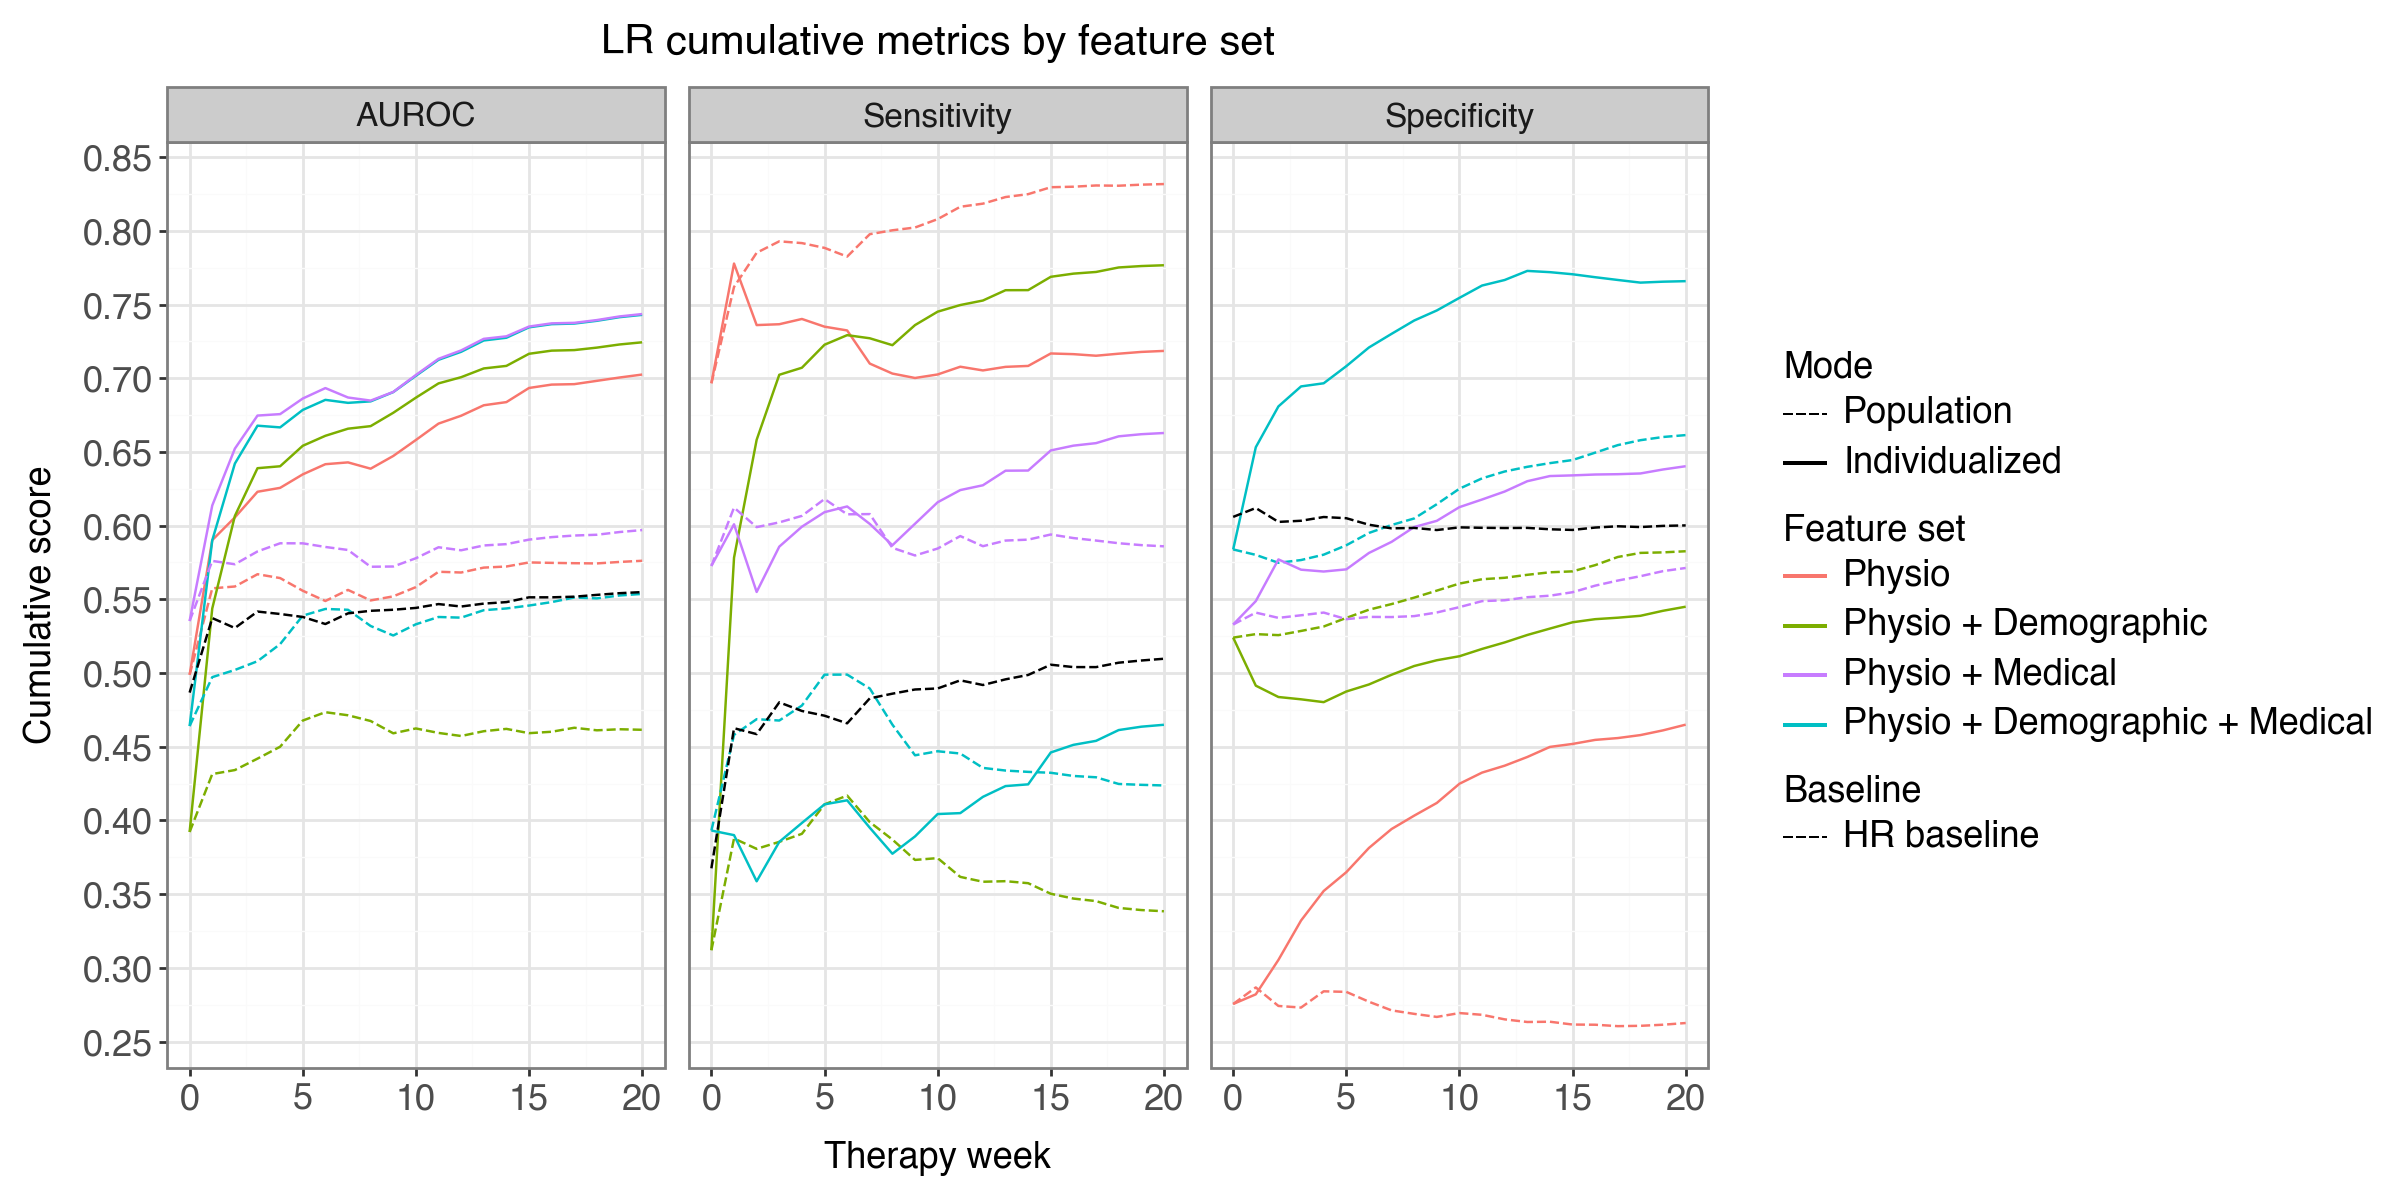

In [10]:
import plotnine as P
from mizani.breaks import breaks_width


def melt_metrics(df):
    """Wide cumulative metrics -> tidy one-row-per-point for plotnine."""
    return df.melt(
        id_vars=["estimator", "feature_set", "mode", "week"],
        value_vars=["auroc", "sensitivity", "specificity"],
        var_name="metric",
        value_name="score",
    ).dropna(subset=["score"])


# Publication styling shared across every metrics plot: larger fonts, bold titles,
# and pretty facet-strip labels (raw metric/estimator keys -> display names).
PUB_THEME = P.theme_bw() + P.theme(
    text=P.element_text(size=13),
    plot_title=P.element_text(size=15, weight="bold"),
    axis_title=P.element_text(size=13),
    legend_title=P.element_text(size=13, weight="bold"),
    strip_text=P.element_text(size=12, weight="bold"),
)
METRIC_LABELS = {
    "auroc": "AUROC",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
}
ESTIMATOR_LABELS = {"xgboost": "XGBoost", "lrl2": "Logistic regression"}
FEATURE_SET_BREAKS = [
    "watch",
    "watch_demographic",
    "watch_medical",
    "watch_demographic_medical",
]
FEATURE_SET_LABELS = [
    "Physio",
    "Physio + Demographic",
    "Physio + Medical",
    "Physio + Demographic + Medical",
]

# LR: population (no_retrain) vs individualized (retrain_dyad) per feature set.
# color encodes feature set, linetype encodes mode. The HR baseline corresponds to
# neither, so it's drawn as its own black dashed layer and carried into the legend as
# a separate "Baseline" group (via a dummy alpha aesthetic, styled with override_aes).
lr_models = melt_metrics(cum[cum["estimator"] == "lrl2"])
hr_baseline = melt_metrics(cum[cum["mode"] == "hr_baseline"])


def plot_metrics(label: str, model_metrics, hr_baseline):
    # Constant column -> its own (alpha) scale => a legend group distinct from
    # Feature set (color) and Mode (linetype).
    hr_baseline = hr_baseline.assign(baseline="HR baseline")
    return (
        P.ggplot(
            model_metrics, P.aes("week", "score", color="feature_set", linetype="mode")
        )
        + P.geom_line()
        + P.geom_line(
            hr_baseline,
            P.aes("week", "score", alpha="baseline"),
            color="black",
            linetype="dashed",
            inherit_aes=False,
        )
        + P.facet_wrap("metric", labeller=lambda s: METRIC_LABELS.get(s, s))
        + P.labs(
            title=f"{label} cumulative metrics by feature set",
            x="Therapy week",
            y="Cumulative score",
            color="Feature set",
            linetype="Mode",
        )
        + PUB_THEME
        + P.theme(figure_size=(12, 6))
        + P.scale_y_continuous(breaks=breaks_width(0.05))
        + P.scale_linetype_manual(
            values=["dashed", "solid"], labels=["Population", "Individualized"]
        )
        + P.scale_color_discrete(breaks=FEATURE_SET_BREAKS, labels=FEATURE_SET_LABELS)
        # Baseline legend: one fully-opaque key, forced to render as a black dashed line.
        + P.scale_alpha_manual(values=[1.0], name="Baseline")
        + P.guides(
            alpha=P.guide_legend(override_aes={"color": "black", "linetype": "dashed"})
        )
    )


p_lr = plot_metrics("LR", lr_models, hr_baseline)
p_lr

### Cumulative metrics by week (XGBoost)


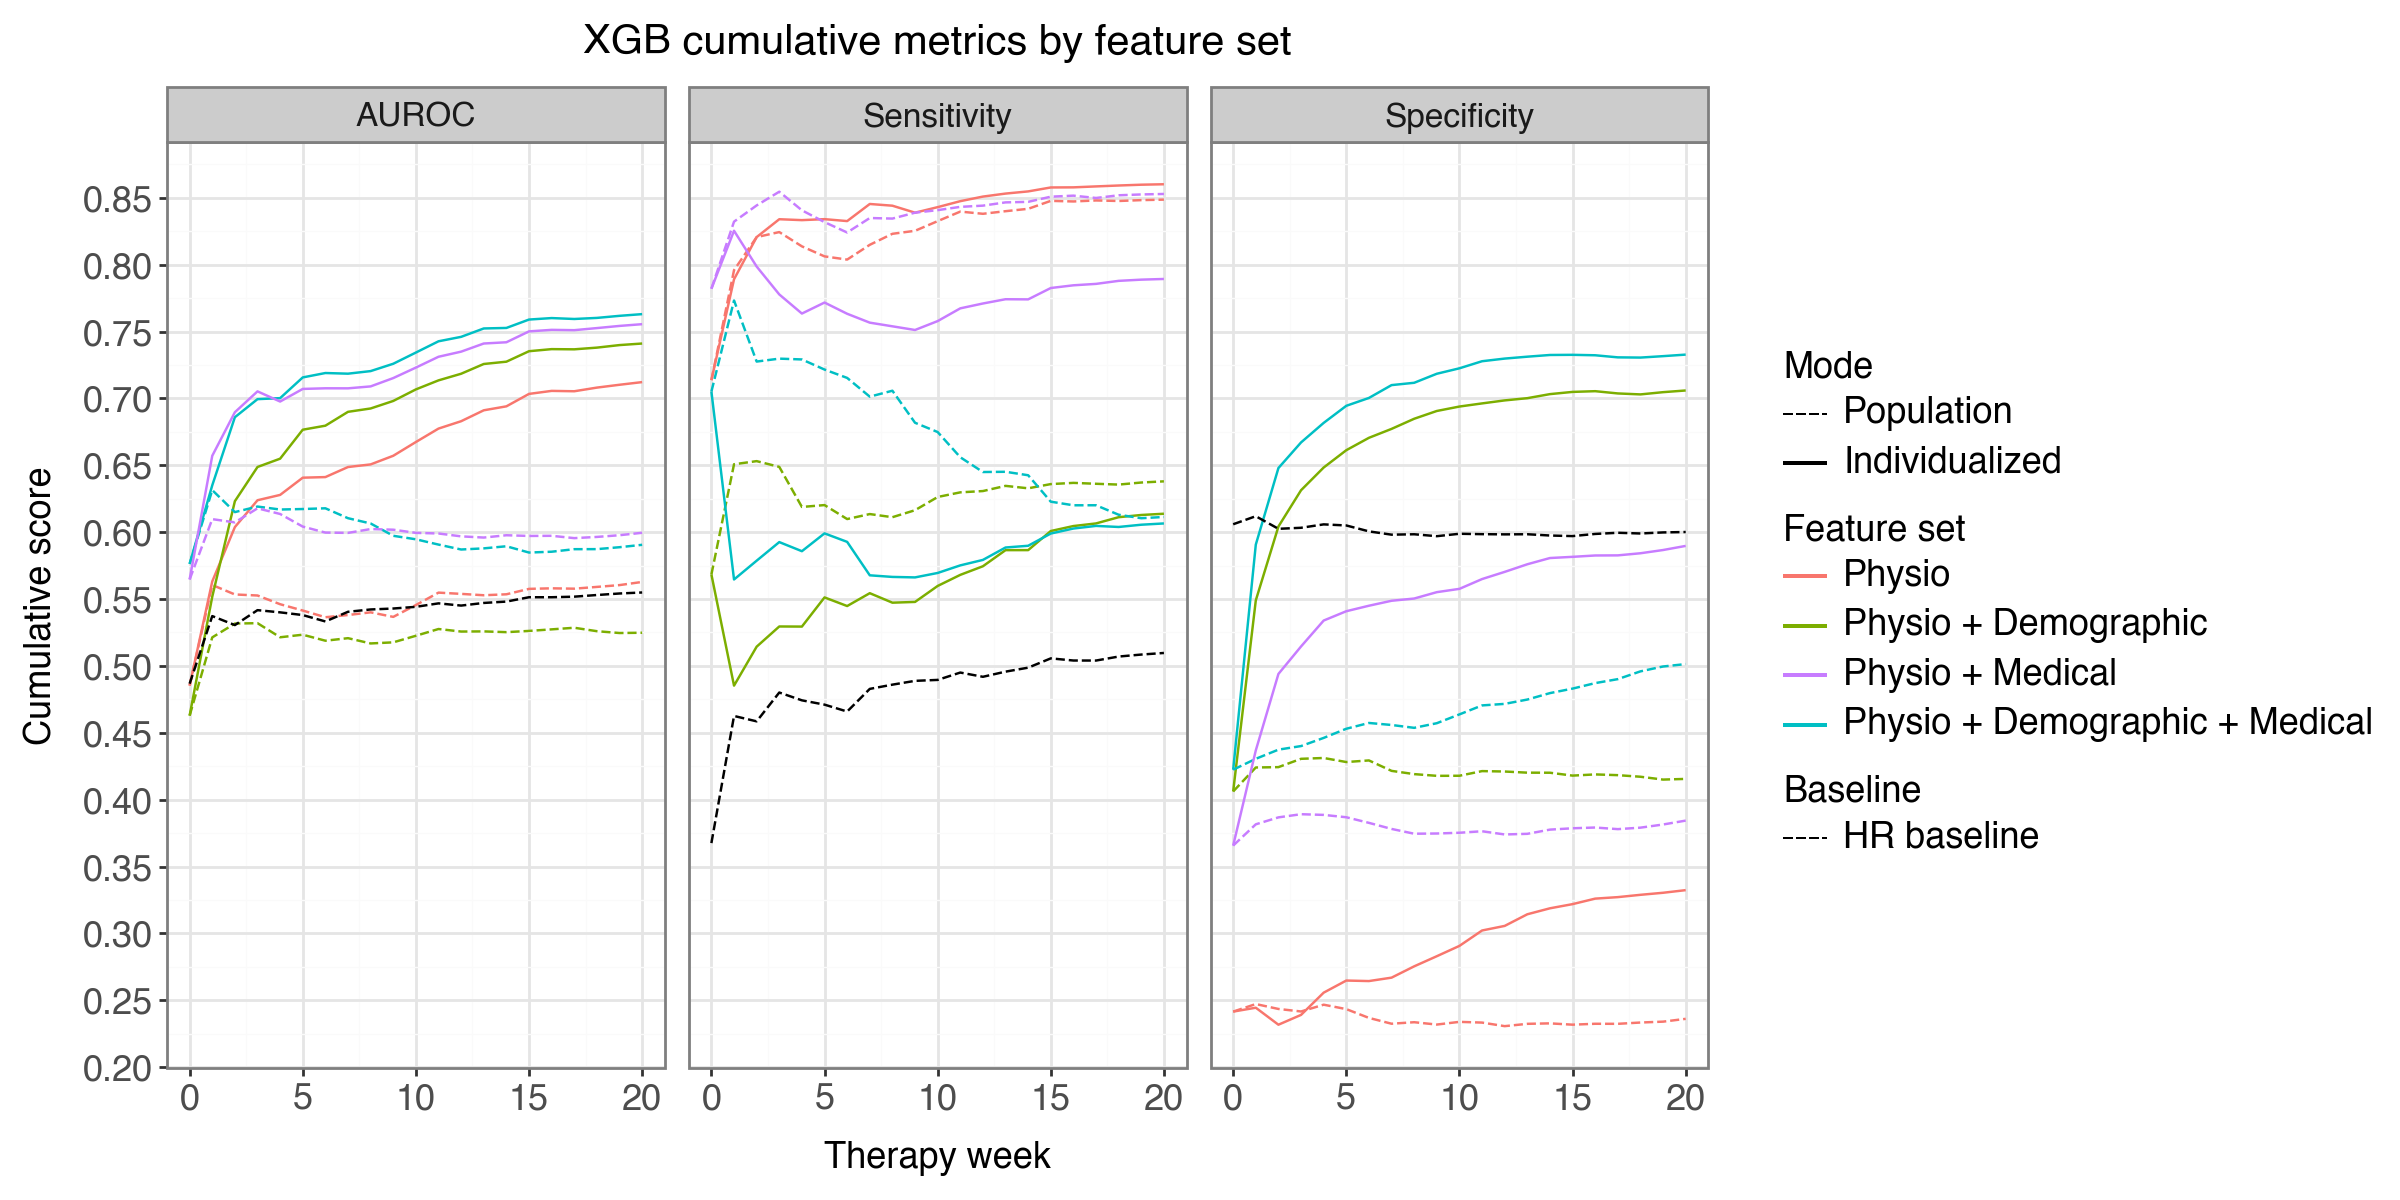

In [11]:
# XGBoost: population (no_retrain) vs individualized (retrain_dyad) per feature set.
# color encodes feature set, linetype encodes mode. The HR baseline is its own black
# dashed layer and appears as a separate "Baseline" legend group (see plot_metrics).
xgb_models = melt_metrics(cum[cum["estimator"] == "xgboost"])
baseline = melt_metrics(cum[cum["mode"] == "hr_baseline"])


p_xgb = plot_metrics("XGB", xgb_models, baseline)
p_xgb

### XGBoost vs logistic regression (individualized retrain, AUROC)


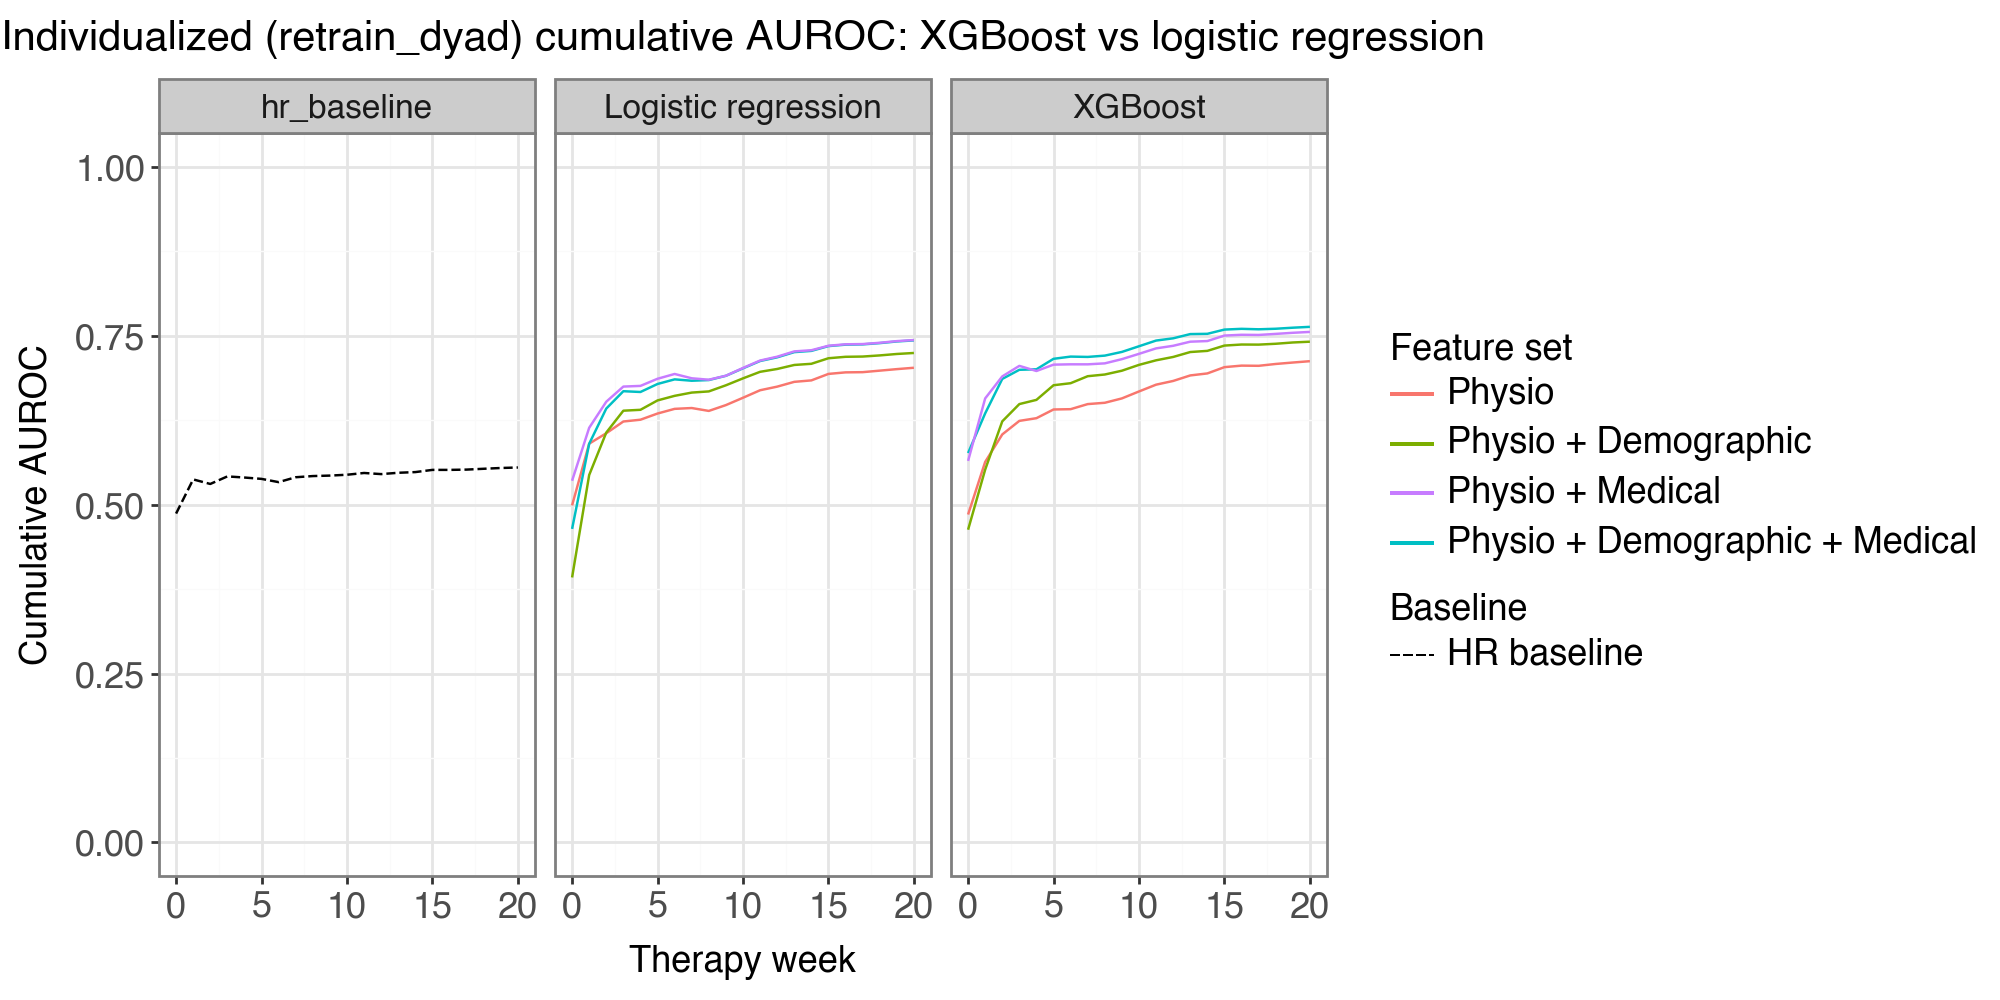

In [12]:
# Individualized (retrain_dyad) cumulative AUROC: XGB vs LR across feature sets.
# color encodes feature set; the HR baseline is its own black dashed layer, carried
# into the legend as a separate "Baseline" group (dummy alpha aesthetic + override_aes).
auroc_models = cum[cum["mode"] == "retrain_dyad"].dropna(subset=["auroc"])
auroc_base = (
    cum[cum["mode"] == "hr_baseline"]
    .dropna(subset=["auroc"])
    .assign(baseline="HR baseline")
)

p_auroc = (
    P.ggplot(auroc_models, P.aes("week", "auroc", color="feature_set"))
    + P.facet_wrap("estimator", labeller=lambda s: ESTIMATOR_LABELS.get(s, s))
    + P.geom_line()
    + P.geom_line(
        auroc_base,
        P.aes("week", "auroc", alpha="baseline"),
        color="black",
        linetype="dashed",
        inherit_aes=False,
    )
    + P.lims(y=(0, 1))
    + P.labs(
        title="Individualized (retrain_dyad) cumulative AUROC: XGBoost vs logistic regression",
        x="Therapy week",
        y="Cumulative AUROC",
        color="Feature set",
    )
    + PUB_THEME
    + P.theme(figure_size=(10, 5))
    + P.scale_color_discrete(breaks=FEATURE_SET_BREAKS, labels=FEATURE_SET_LABELS)
    # Baseline legend: one fully-opaque key, forced to render as a black dashed line.
    + P.scale_alpha_manual(values=[1.0], name="Baseline")
    + P.guides(
        alpha=P.guide_legend(override_aes={"color": "black", "linetype": "dashed"})
    )
)
p_auroc

## SHAP — population model at week 0

The closing analysis: SHAP attribution for the **week-0 population model** — the
static base model that scores week 0 with no retraining yet — on the **full** feature
set (`watch_demographic_medical`) and the **XGBoost** estimator (`TreeExplainer`
needs a tree model). It is loaded from the cache written by the training loop and
explained over the Active-arm (test) rows it scores. The beeswarm shows the
direction/magnitude of each feature's positive-class (tantrum) contribution; the bar
shows mean |SHAP| (global importance). Features feed the pipeline's
`OneHotEncoder` + passthrough preprocessor, so SHAP is computed on the encoded
matrix (medical / demographic categories become one-hot columns).


top features by mean |SHAP| (population, week 0):
steps_0_to_15m                              0.282457
Pre.ECBI.Prob                               0.223017
hr_moving_avg_10m                           0.187305
Child.On.Non.Stimulants_False               0.138034
Education Status_2 year associate degree    0.120667
light_pct_T-1                               0.102963
Diag.ADHD_False                             0.075736
hr_moving_min_10m                           0.074706
Pre.ECBI                                    0.070579
total_sleep_T-1                             0.070416
awake_T-1                                   0.058202
therapy_length_days                         0.052325
awake_T-2                                   0.046909
hr_moving_max_10m                           0.031125
rem_pct_T-1                                 0.030267
dtype: float32


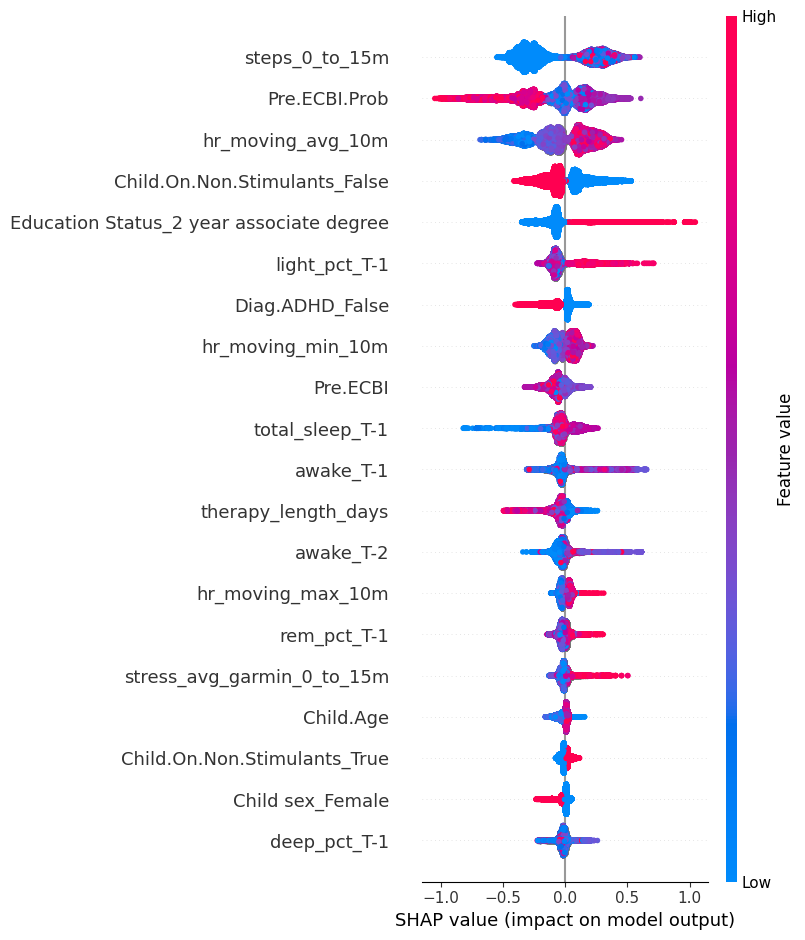

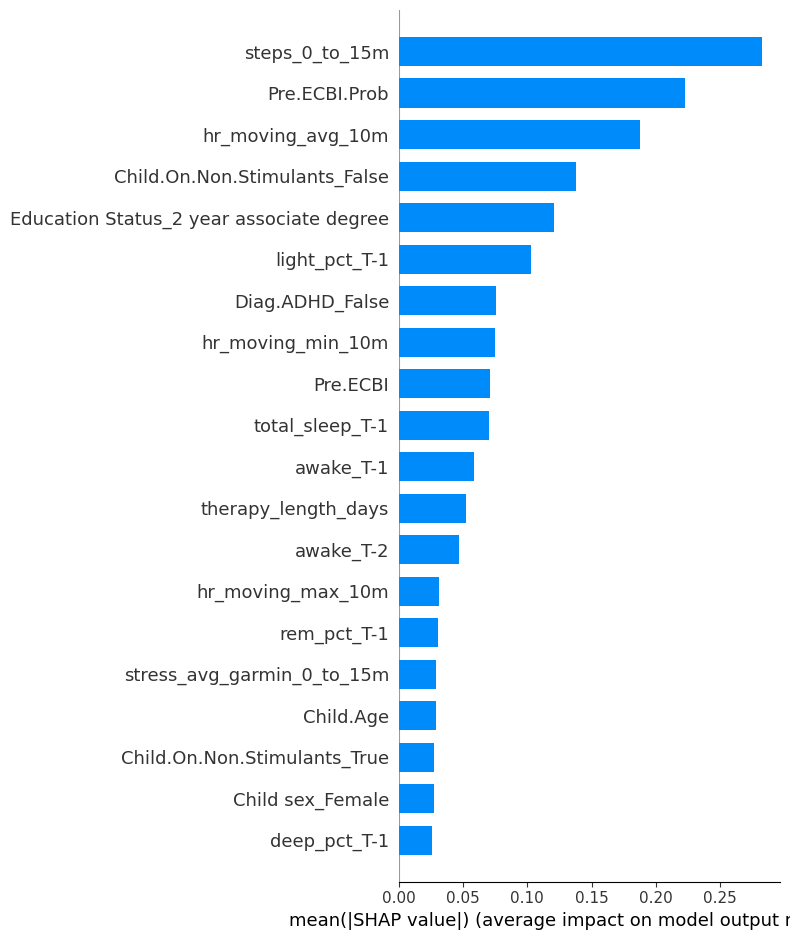

In [13]:
import shap

fs_cols = FEATURE_SETS[E.FULL_FEATURE_SET]
df_pop = E.select_features(df_pop_full, fs_cols)
df_test = E.select_features(df_test_full, fs_cols)

# Population (week-0) XGBoost model on the full feature set. get_config loads the
# cached FLAML config; fit_model loads the cached population.joblib (fits on a miss).
config = E.get_config(
    "xgboost",
    df_pop,
    MODELS_DIR / "xgboost" / E.FULL_FEATURE_SET / "config.joblib",
    max_iter=FLAML_MAX_ITER,
    time_budget=FLAML_TIME_BUDGET,
    random_state=RANDOM_STATE,
    verbose=0,
)
pop_model = E.fit_model(
    df_pop,
    "xgboost",
    config,
    cache_path=MODELS_DIR / "xgboost" / E.FULL_FEATURE_SET / "population.joblib",
)

X_test_all, _ = F.prep_X_y(df_test, RESPONSE_COLUMN)
X_sample = X_test_all.sample(min(100_000, len(X_test_all)), random_state=RANDOM_STATE)

sv, X_enc = E.shap_for_model(pop_model, X_sample)
importance = E.mean_abs_shap(sv, X_enc).sort_values(ascending=False)
print("top features by mean |SHAP| (population, week 0):")
print(importance.head(15))

shap.summary_plot(sv, X_enc, show=True)
shap.summary_plot(sv, X_enc, plot_type="bar", show=True)

## SHAP — week-5 individualized (`retrain_dyad`) model

The counterpart to the population analysis above: SHAP attribution for the **week-5
individualized model**. We rebuild each active dyad's week-5 model exactly as the
retrain loop does — population + that dyad's accumulated history for weeks `< 5`,
with the dyad's rows **upweighted** by `level` (= number of active dyads) — then
explain that dyad's week-5 rows and **pool** the SHAP values across all dyads into
one cohort-level view. Same XGBoost estimator and full feature set
(`watch_demographic_medical`) as the population model, so the two are directly
comparable. Models are loaded from the cache written by the training loop (fit on a
cache miss). Because the `OneHotEncoder` emits a different column set per dyad
(medical/demographic categories that actually occur), each dyad's contributions are
aligned to the union of columns (missing category ⇒ contribution 0) before pooling.


week 5: dyad SHAP:   0%|          | 0/28 [00:00<?, ?it/s]

pooled 15,450 week-5 rows from 25 dyads


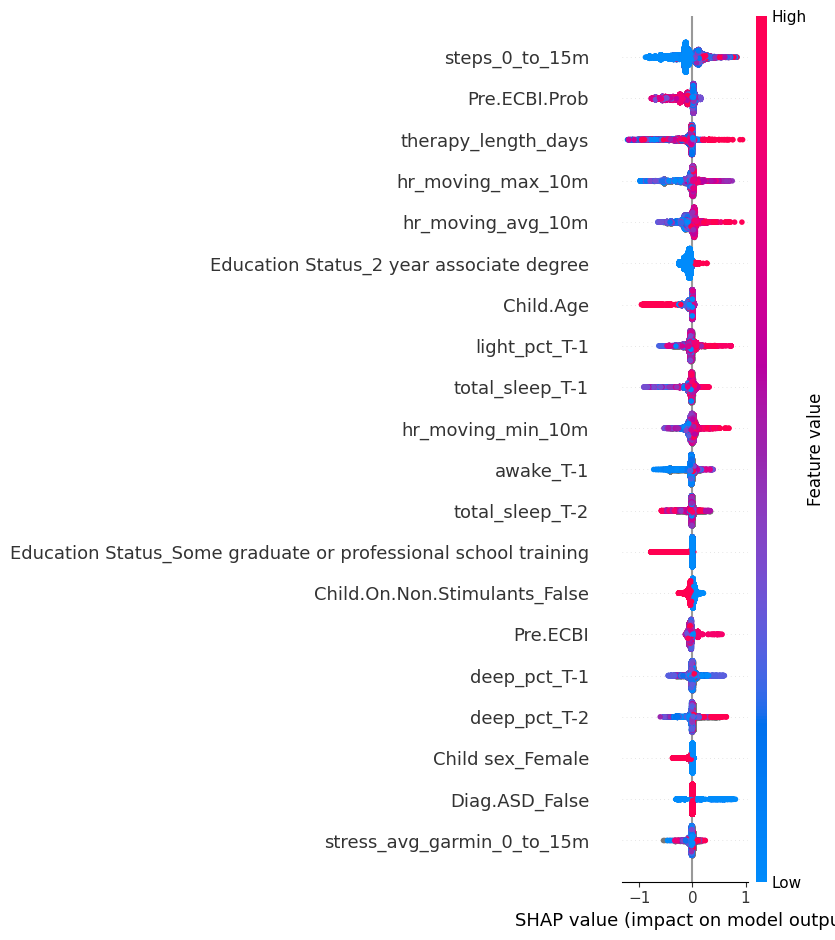

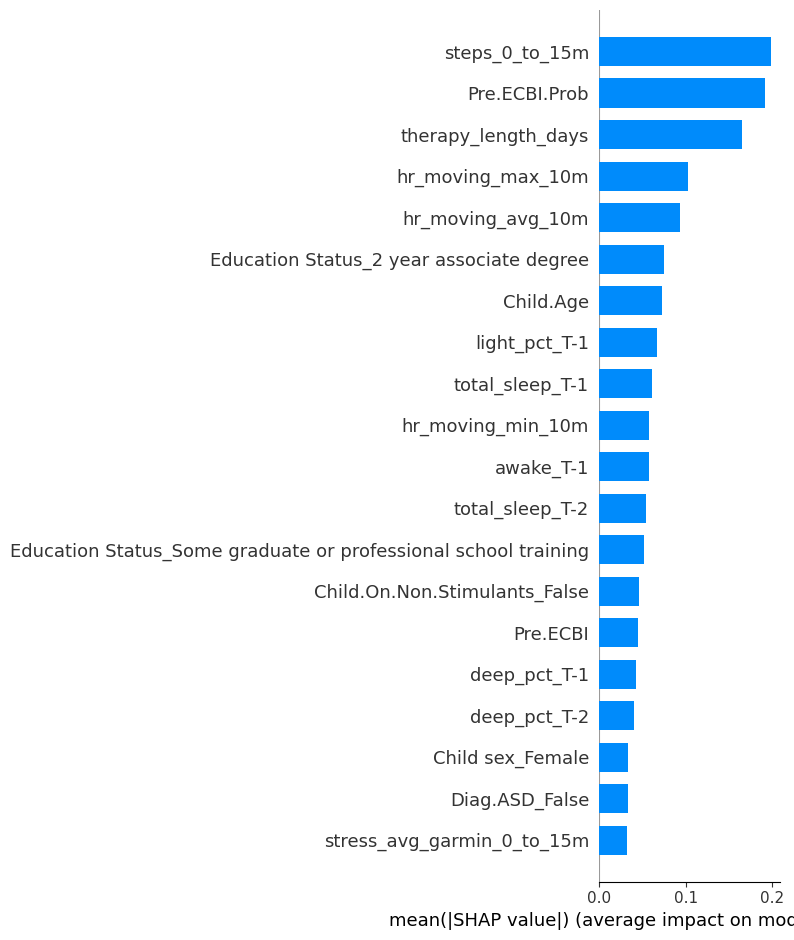

In [14]:
import numpy as np
from tqdm.auto import tqdm

# Reuses df_pop / df_test / config (xgboost, full feature set) from the population
# SHAP cell above.
WEEK5 = 5
level = df_test["dyad"].nunique()

sv_frames, X_frames = [], []
for dyad, d in tqdm(df_test.groupby("dyad"), total=level, desc="week 5: dyad SHAP"):
    history = d[d["therapy_week"] < WEEK5]
    week5_rows = d[d["therapy_week"] == WEEK5]
    if history.empty or week5_rows.empty:
        continue
    cache_path = (
        MODELS_DIR
        / "xgboost"
        / E.FULL_FEATURE_SET
        / "retrain_dyad"
        / f"week_{WEEK5}"
        / f"dyad_{E._safe(dyad)}.joblib"
    )
    if cache_path.exists():
        model = F.load_model(str(cache_path))
    else:
        # Faithful to eval_weekly("retrain_dyad"): upweight the dyad's history
        # (weights line up with combined's row order -- pop first, then the dyad).
        combined = pd.concat([df_pop, history], ignore_index=True)
        weights = np.concatenate([np.ones(len(df_pop)), np.full(len(history), level)])
        model = E.fit_model(
            combined, "xgboost", config, cache_path=cache_path, sample_weight=weights
        )
    Xw, _ = F.prep_X_y(week5_rows, RESPONSE_COLUMN)
    sv_w, X_enc_w = E.shap_for_model(model, Xw)
    # OneHotEncoder emits a different column set per dyad -> carry names, union below.
    sv_frames.append(pd.DataFrame(sv_w, columns=X_enc_w.columns))
    X_frames.append(X_enc_w)

# A one-hot column missing for a dyad means that category never occurred there ->
# its SHAP contribution and feature value are both 0 for those rows.
all_cols = sorted(set().union(*(f.columns for f in X_frames)))
week5_sv = pd.concat(
    (f.reindex(columns=all_cols, fill_value=0.0) for f in sv_frames), ignore_index=True
).to_numpy()
week5_X = pd.concat(
    (f.reindex(columns=all_cols, fill_value=0.0) for f in X_frames), ignore_index=True
)
week5_importance = E.mean_abs_shap(week5_sv, week5_X)
print(f"pooled {len(week5_X):,} week-5 rows from {len(sv_frames)} dyads")

shap.summary_plot(week5_sv, week5_X, show=True)
shap.summary_plot(week5_sv, week5_X, plot_type="bar", show=True)

### Change in importance — population vs week-5 `retrain_dyad`

Mean |SHAP| per feature for both models, side by side — the headline view of how
per-dyad retraining shifts which features drive the tantrum prediction.


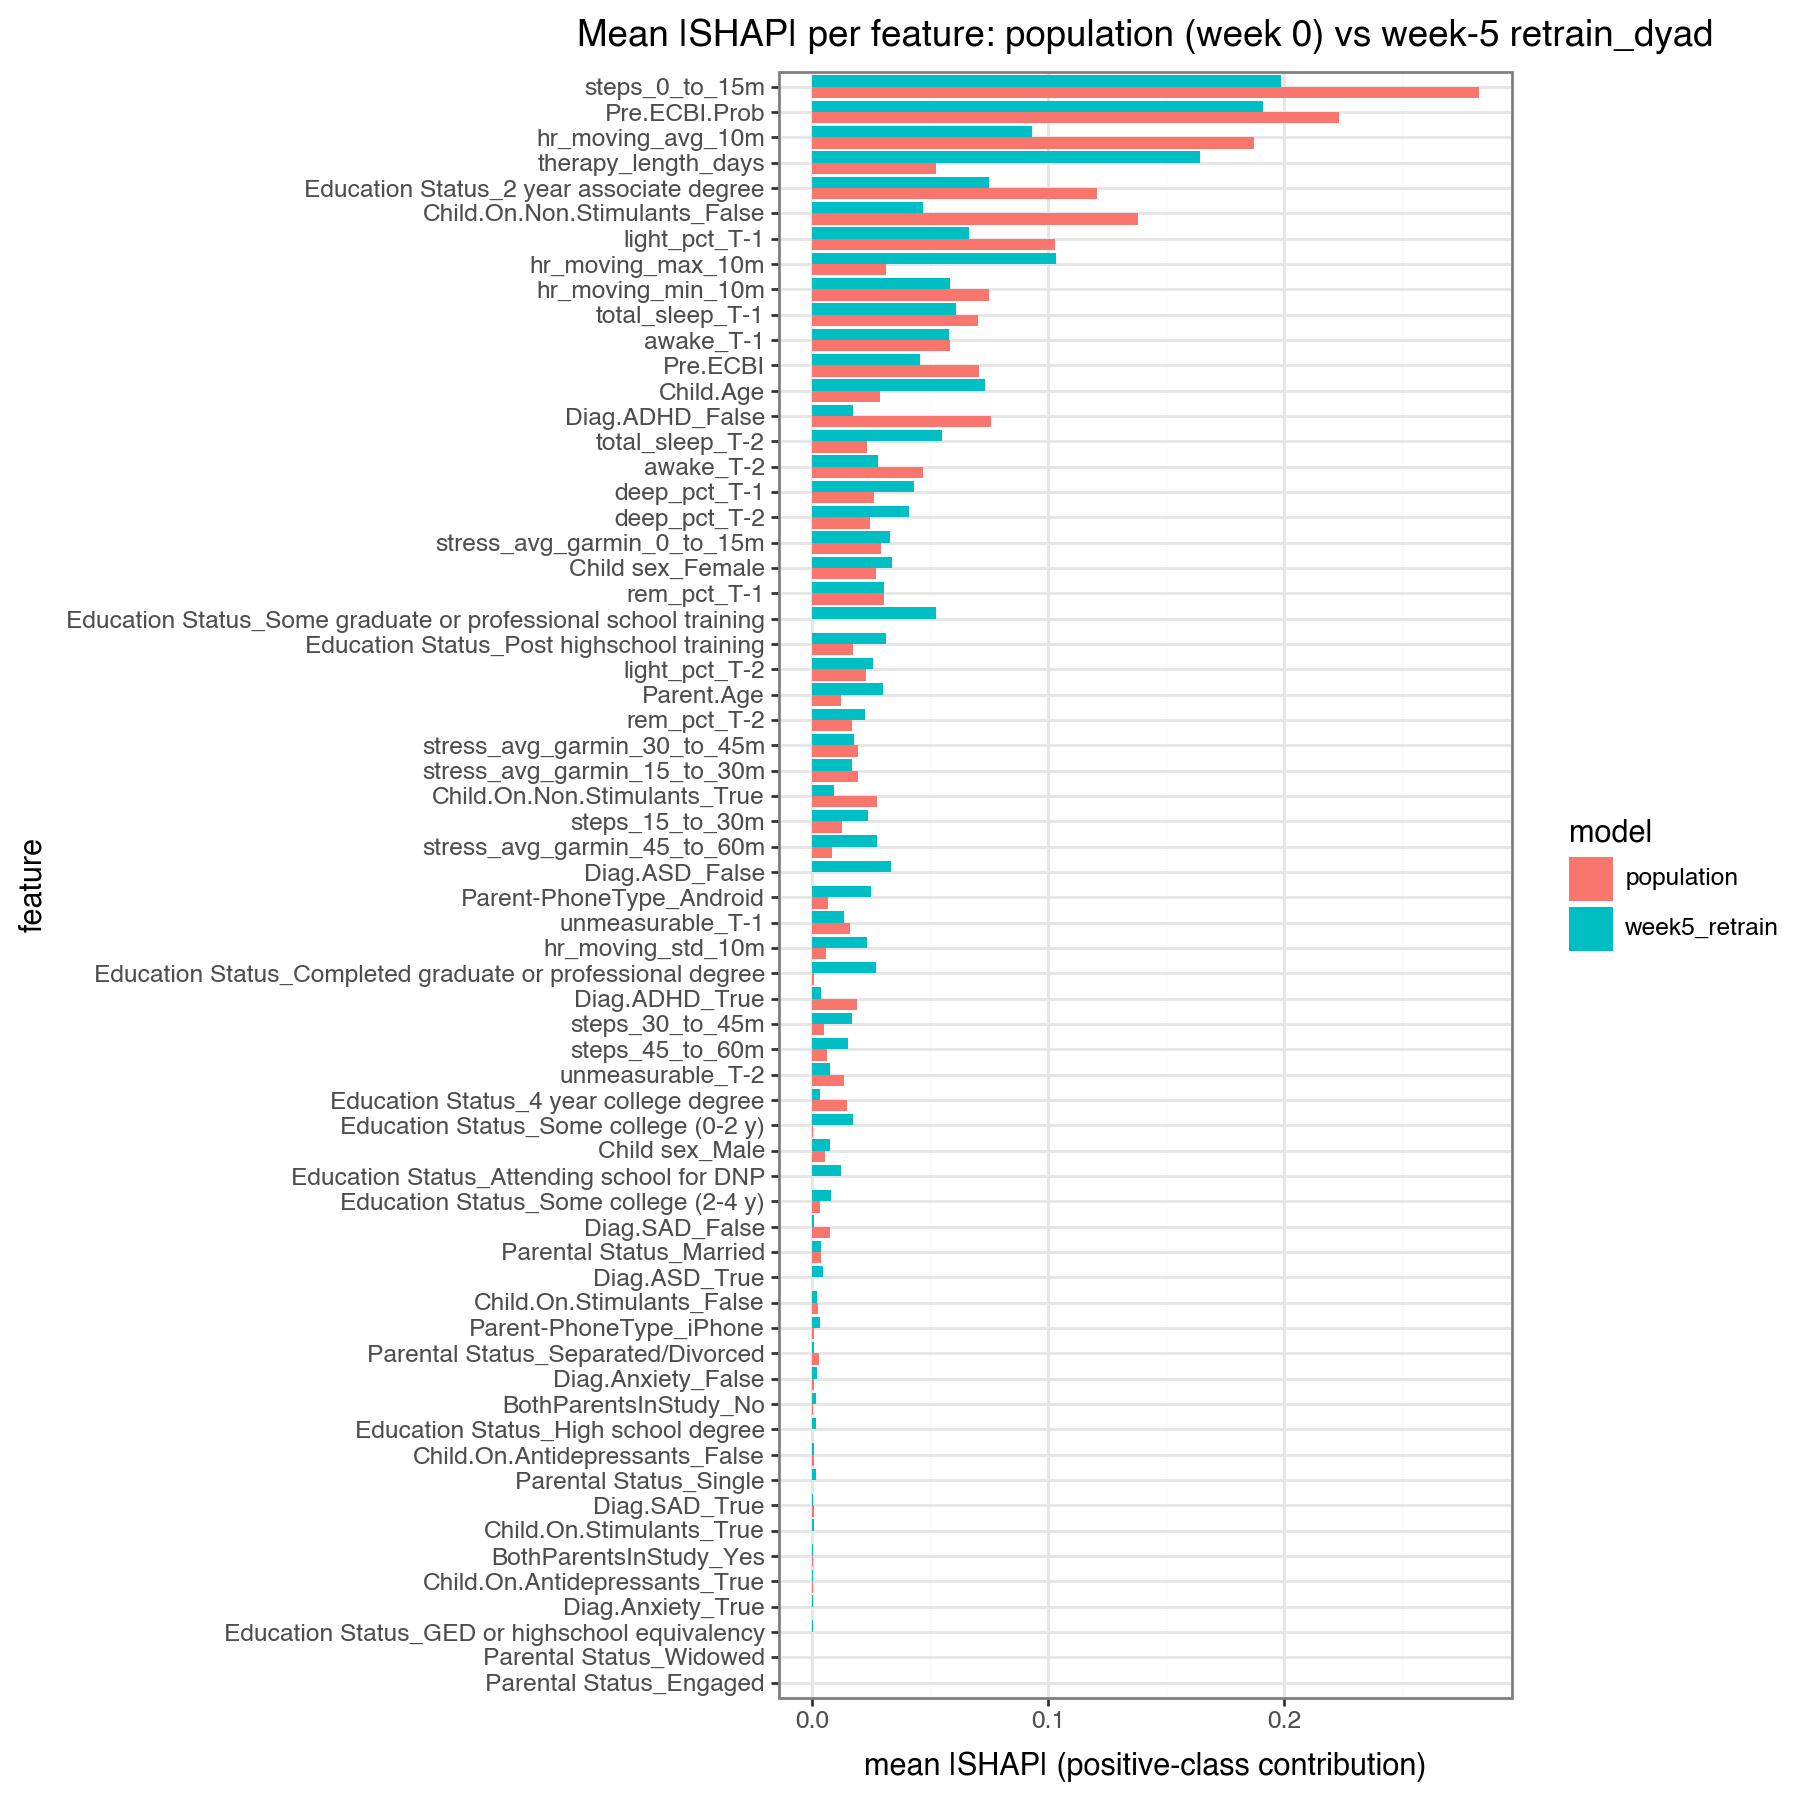

In [15]:
# Population model mean |SHAP| (from the SHAP cell above: sv / X_enc).
pop_importance = E.mean_abs_shap(sv, X_enc)

# Align both models' mean |SHAP| on feature name (outer-join: a one-hot category
# absent from one model's data fills to 0), then go tidy for plotnine.
importance_cmp = (
    pd.concat({"population": pop_importance, "week5_retrain": week5_importance}, axis=1)
    .fillna(0.0)
    .rename_axis("feature")
    .reset_index()
)
# Order features by combined importance so the chart reads top-down.
order = (
    importance_cmp.assign(total=lambda t: t["population"] + t["week5_retrain"])
    .sort_values("total")["feature"]
    .tolist()
)
imp_long = importance_cmp.melt(
    id_vars="feature", var_name="model", value_name="mean_abs_shap"
)
imp_long["feature"] = pd.Categorical(
    imp_long["feature"], categories=order, ordered=True
)

(
    P.ggplot(imp_long, P.aes("feature", "mean_abs_shap", fill="model"))
    + P.geom_col(position="dodge")
    + P.coord_flip()
    + P.scale_x_discrete(limits=order)
    + P.labs(
        title="Mean |SHAP| per feature: population (week 0) vs week-5 retrain_dyad",
        x="feature",
        y="mean |SHAP| (positive-class contribution)",
        fill="model",
    )
    + P.theme_bw()
    + P.theme(figure_size=(9, 9))
)

## How the top SHAP features shift week to week

The two Sankey diagrams below trace the **top-15 features by mean |SHAP|** across the
individualized (`retrain_dyad`) XGBoost models over therapy weeks 0–12. For each week
`W` the cohort-level SHAP is rebuilt exactly as the week-5 cell does — population +
each active dyad's history for weeks `< W`, the dyad's rows upweighted by `level`,
pooled across dyads — then one-hot columns are summed back onto their **base feature**
so the lines read as feature names. Week 0 has no history for any dyad, so it reduces
to the population model (matching the week-0 SHAP cell above).

These are **bump-style** Sankeys: every feature that reaches the top-15 in _any_ shown
week gets one continuous, per-feature-colored line across all columns. Within each week
the top-15 sit in the upper band ordered by rank (most important on top); a feature that
has fallen out of the top-15 drops into a fixed bottom zone (ordered by its true rank),
so its line **dips down** when it leaves the top-15 and **rises** when it re-enters — and
no line ever runs off the plot. A bold black dashed line marks the top-15 cutoff. Each line
is labeled once, in week 0, as `#<rank> <feature>`, and by `#<rank>` alone thereafter.
Lines are constant width (they trace rank movement, not |SHAP| magnitude); segments
running through the bottom zone are drawn faint. The first diagram shows weeks
`[0, 2, 4, 6, 8, 10, 12]`; the second is the coarse `[0, 6, 12]`. The Physio + Medical
and Physio-only sections that follow repeat this with the **top 10**.


In [16]:
# Per-week grouped mean|SHAP| for the retrain_dyad XGBoost models (weeks 0-12).
# Reuses df_pop / df_test / config / pop_model / level from the SHAP cells above.
SANKEY_WEEKS = [0, 2, 4, 6, 8, 10, 12]  # union of both diagrams' weeks

# Map an encoded (post-OneHotEncoder) column back to its base feature. The preprocessor
# uses verbose_feature_names_out=False, so a categorical column `c` emits f"{c}_{value}"
# and numerics pass through unchanged -> the longest matching categorical prefix wins.
_CAT_COLS = sorted(E.CATEGORICAL_FEATURES, key=len, reverse=True)


def _base_feature(name: str) -> str:
    for c in _CAT_COLS:
        if name == c or name.startswith(c + "_"):
            return c
    return name


def _group_to_base(importance: pd.Series) -> pd.Series:
    """Sum mean|SHAP| of one-hot columns back onto their base feature."""
    return importance.groupby(importance.index.map(_base_feature)).sum()


def pooled_importance_for_week(week: int) -> pd.Series:
    """Grouped mean|SHAP| per base feature for the week-`week` retrain_dyad cohort."""
    if week == 0:
        # No dyad has history before week 0 -> the individualized model == population.
        week0_rows = df_test[df_test["therapy_week"] == 0]
        Xw, _ = F.prep_X_y(week0_rows, RESPONSE_COLUMN)
        sv_w, X_enc_w = E.shap_for_model(pop_model, Xw)
        return _group_to_base(E.mean_abs_shap(sv_w, X_enc_w))

    sv_frames, X_frames = [], []
    for dyad, d in df_test.groupby("dyad"):
        history = d[d["therapy_week"] < week]
        week_rows = d[d["therapy_week"] == week]
        if history.empty or week_rows.empty:
            continue
        cache_path = (
            MODELS_DIR
            / "xgboost"
            / E.FULL_FEATURE_SET
            / "retrain_dyad"
            / f"week_{week}"
            / f"dyad_{E._safe(dyad)}.joblib"
        )
        if cache_path.exists():
            model = F.load_model(str(cache_path))
        else:
            combined = pd.concat([df_pop, history], ignore_index=True)
            weights = np.concatenate(
                [np.ones(len(df_pop)), np.full(len(history), level)]
            )
            model = E.fit_model(
                combined,
                "xgboost",
                config,
                cache_path=cache_path,
                sample_weight=weights,
            )
        Xw, _ = F.prep_X_y(week_rows, RESPONSE_COLUMN)
        sv_w, X_enc_w = E.shap_for_model(model, Xw)
        sv_frames.append(pd.DataFrame(sv_w, columns=X_enc_w.columns))
        X_frames.append(X_enc_w)

    # Align each dyad's one-hot columns onto the union (missing category => 0), then pool.
    all_cols = sorted(set().union(*(f.columns for f in X_frames)))
    sv = pd.concat(
        (f.reindex(columns=all_cols, fill_value=0.0) for f in sv_frames),
        ignore_index=True,
    ).to_numpy()
    X = pd.concat(
        (f.reindex(columns=all_cols, fill_value=0.0) for f in X_frames),
        ignore_index=True,
    )
    return _group_to_base(E.mean_abs_shap(sv, X))


importance_by_week = {}
for w in tqdm(SANKEY_WEEKS, desc="per-week SHAP importance"):
    importance_by_week[w] = pooled_importance_for_week(w)
print("computed grouped mean|SHAP| for weeks:", list(importance_by_week))


per-week SHAP importance:   0%|          | 0/7 [00:00<?, ?it/s]

computed grouped mean|SHAP| for weeks: [0, 2, 4, 6, 8, 10, 12]


In [17]:
import colorsys

import plotly.graph_objects as go

TOP_N = 10


def _feature_color_map(features):
    """Stable, visually distinct RGB per feature (evenly spaced hues)."""
    feats = list(features)
    n = max(len(feats), 1)
    return {
        f: tuple(int(c * 255) for c in colorsys.hsv_to_rgb(i / n, 0.55, 0.9))
        for i, f in enumerate(feats)
    }


def feature_sankey(weeks, importance_by_week, top_n=TOP_N, title=""):
    """Bump-style Sankey of the top-`top_n` SHAP features across `weeks`.

    Every feature that is top-`top_n` in *any* shown week gets one continuous line across
    all columns (so if 3 features dip in and out of the top-n, there are top_n+3 lines).
    In each week the top-`top_n` occupy the upper band ordered by rank (most important on
    top); features that have fallen out sit in a fixed bottom zone ordered by their true
    rank, so a line dips down when it leaves the top-`top_n` and rises when it re-enters,
    and no line ever runs off the plot. A bold dashed horizontal line marks the top-`top_n`
    cutoff (just below the #`top_n` row). Color is per feature. Each line is named once, in
    week 0 ("#<rank> <feature>"), and shows the rank alone ("#<rank>") thereafter — so
    labels are consistent from column to column. Ribbons are constant width — they trace
    rank movement, not |SHAP| magnitude.
    """
    full = {w: importance_by_week[w].sort_values(ascending=False) for w in weeks}
    top = {w: full[w].head(top_n) for w in weeks}
    top_set = {w: set(top[w].index) for w in weeks}
    ranks = {w: {f: i for i, f in enumerate(full[w].index)} for w in weeks}

    # Every feature ever in the top-n gets a lane in every column -> continuous lines.
    tracked = sorted({f for w in weeks for f in top[w].index})
    K = len(tracked)
    cmap = _feature_color_map(tracked)
    ncols = len(weeks)

    def rank_of(w, feat):
        return ranks[w].get(feat, len(full[w]))  # unseen that week -> very bottom

    # Per-week vertical order: top-n first (by rank), then fallen-out features (by rank).
    order = {
        w: sorted(tracked, key=lambda f: (0 if f in top_set[w] else 1, rank_of(w, f)))
        for w in weeks
    }
    lane = {w: {f: i for i, f in enumerate(order[w])} for w in weeks}

    def col_x(ci):
        return 0.001 if ncols == 1 else 0.001 + 0.998 * ci / (ncols - 1)

    def lane_y(li):
        return 0.03 + 0.94 * (li + 0.5) / K  # node-domain y (0 = top) for lane index li

    node_idx, node_labels, node_colors, node_x, node_y = {}, [], [], [], []
    named = set()  # name each line once, in week 0; rank-only afterward
    for ci, w in enumerate(weeks):  # week 0 first -> every line is named in column 0
        for feat in order[w]:
            node_idx[(w, feat)] = len(node_labels)
            in_top = feat in top_set[w]
            r1 = rank_of(w, feat) + 1
            if feat in named:
                node_labels.append(f"#{r1}")
            else:
                node_labels.append(f"#{r1} {feat}")
                named.add(feat)
            r, g, b = cmap[feat]
            node_colors.append(f"rgba({r},{g},{b},{0.95 if in_top else 0.35})")
            node_x.append(col_x(ci))
            node_y.append(lane_y(lane[w][feat]))

    # One ribbon per feature between every adjacent pair of shown weeks (continuous line).
    s_idx, t_idx, values, link_colors = [], [], [], []
    for ci in range(ncols - 1):
        a, b = weeks[ci], weeks[ci + 1]
        for feat in tracked:
            s_idx.append(node_idx[(a, feat)])
            t_idx.append(node_idx[(b, feat)])
            values.append(
                1.0
            )  # constant width: lines trace rank movement, not magnitude
            r, g, bb = cmap[feat]
            in_band = feat in top_set[a] or feat in top_set[b]  # touches the top-n band
            link_colors.append(f"rgba({r},{g},{bb},{0.5 if in_band else 0.13})")

    # Text summary of top-n churn (nothing is silently dropped).
    for a, b in zip(weeks[:-1], weeks[1:]):
        entered = sorted(top_set[b] - top_set[a])
        left = sorted(top_set[a] - top_set[b])
        print(
            f"week {a:>2} -> {b:>2}   entered top-{top_n}: {entered or '-'}   left: {left or '-'}"
        )

    fig = go.Figure(
        go.Sankey(
            arrangement="fixed",  # honor node y exactly so the top-n divider lines up
            node=dict(
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y,
                pad=6,
                thickness=13,
                line=dict(color="rgba(0,0,0,0.3)", width=0.5),
            ),
            link=dict(source=s_idx, target=t_idx, value=values, color=link_colors),
        )
    )
    # Bold dashed divider just below the #top_n row (node y=0 is the top -> flip to paper y).
    if K > top_n:
        y_div = 1.0 - lane_y(top_n - 0.5)  # boundary between lane top_n-1 and top_n
        fig.add_shape(
            type="line",
            xref="paper",
            yref="paper",
            x0=0,
            x1=1,
            y0=y_div,
            y1=y_div,
            line=dict(color="rgba(0,0,0,0.9)", width=3, dash="dash"),
        )
    for ci, w in enumerate(weeks):
        fig.add_annotation(
            x=0.0 if ncols == 1 else ci / (ncols - 1),
            y=1.05,
            xref="paper",
            yref="paper",
            showarrow=False,
            text=f"<b>week {w}</b>",
            font=dict(size=12),
        )
    fig.update_layout(
        title_text=title,
        font_size=11,
        width=190 * ncols + 240,
        height=max(620, 42 * K),
        margin=dict(t=90, l=20, r=20, b=20),
    )
    return fig


# Full feature set uses the top 15 features (Physio+Medical below keeps the default 10).
fig_fine = feature_sankey(
    [0, 2, 4, 6, 8, 10, 12],
    importance_by_week,
    top_n=15,
    title="Top-15 SHAP features by week (Physio, Demo, Medical) — weeks 0-12",
)
fig_fine.show()


week  0 ->  2   entered top-15: ['Child.Age', 'Diag.ASD', 'Parent.Age', 'total_sleep_T-2']   left: ['Diag.ADHD', 'awake_T-1', 'awake_T-2', 'stress_avg_garmin_0_to_15m']
week  2 ->  4   entered top-15: ['awake_T-1']   left: ['Parent.Age']
week  4 ->  6   entered top-15: ['Child sex', 'deep_pct_T-2']   left: ['Pre.ECBI', 'awake_T-1']
week  6 ->  8   entered top-15: ['awake_T-1']   left: ['Child.On.Non.Stimulants']
week  8 -> 10   entered top-15: ['rem_pct_T-2', 'stress_avg_garmin_0_to_15m']   left: ['awake_T-1', 'hr_moving_min_10m']
week 10 -> 12   entered top-15: ['awake_T-1', 'light_pct_T-2']   left: ['rem_pct_T-2', 'stress_avg_garmin_0_to_15m']


In [18]:
# Coarser view: start / mid / end of the studied window.
fig_coarse = feature_sankey(
    [0, 6, 12],
    importance_by_week,
    top_n=15,
    title="Top-15 SHAP features (Physio, Demo, Medical) — weeks 0, 6, 12",
)
fig_coarse.show()


week  0 ->  6   entered top-15: ['Child sex', 'Child.Age', 'Diag.ASD', 'deep_pct_T-2', 'total_sleep_T-2']   left: ['Diag.ADHD', 'Pre.ECBI', 'awake_T-1', 'awake_T-2', 'stress_avg_garmin_0_to_15m']
week  6 -> 12   entered top-15: ['awake_T-1', 'light_pct_T-2']   left: ['Child.On.Non.Stimulants', 'hr_moving_min_10m']


## The same, for the Physio + Medical feature set (`watch_medical`)

The identical week-to-week top-SHAP analysis, but on the **`watch_medical`** feature
set (physio watch features + medical, **no demographics**) instead of the full stack.
Same XGBoost `retrain_dyad` models, same pooling and base-feature grouping, same two
Sankey views — so this is directly comparable to the full-set diagrams above and
isolates how dropping the demographic columns reshuffles which features drive the
prediction over time. Models are loaded from the `watch_medical` caches written by the
training loop (fit on a cache miss).


In [19]:
# Per-week grouped mean|SHAP| for the Physio+Medical (watch_medical) retrain_dyad models.
# Mirrors the full-set cell above but is parameterized on the feature set so the two are
# built identically. Reuses _group_to_base / feature_sankey / SANKEY_WEEKS from above.
FS_MED = "watch_medical"
fs_cols_med = FEATURE_SETS[FS_MED]
df_pop_med = E.select_features(df_pop_full, fs_cols_med)
df_test_med = E.select_features(df_test_full, fs_cols_med)

config_med = E.get_config(
    "xgboost",
    df_pop_med,
    MODELS_DIR / "xgboost" / FS_MED / "config.joblib",
    max_iter=FLAML_MAX_ITER,
    time_budget=FLAML_TIME_BUDGET,
    random_state=RANDOM_STATE,
    verbose=0,
)
pop_model_med = E.fit_model(
    df_pop_med,
    "xgboost",
    config_med,
    cache_path=MODELS_DIR / "xgboost" / FS_MED / "population.joblib",
)


def pooled_importance_for_week_fs(week, *, fs_name, df_pop, df_test, config, pop_model):
    """Feature-set-parameterized twin of pooled_importance_for_week: grouped mean|SHAP|
    per base feature for the week-`week` retrain_dyad cohort of `fs_name`."""
    if week == 0:
        # No dyad has history before week 0 -> the individualized model == population.
        week0_rows = df_test[df_test["therapy_week"] == 0]
        Xw, _ = F.prep_X_y(week0_rows, RESPONSE_COLUMN)
        sv_w, X_enc_w = E.shap_for_model(pop_model, Xw)
        return _group_to_base(E.mean_abs_shap(sv_w, X_enc_w))

    lvl = df_test["dyad"].nunique()
    sv_frames, X_frames = [], []
    for dyad, d in df_test.groupby("dyad"):
        history = d[d["therapy_week"] < week]
        week_rows = d[d["therapy_week"] == week]
        if history.empty or week_rows.empty:
            continue
        cache_path = (
            MODELS_DIR
            / "xgboost"
            / fs_name
            / "retrain_dyad"
            / f"week_{week}"
            / f"dyad_{E._safe(dyad)}.joblib"
        )
        if cache_path.exists():
            model = F.load_model(str(cache_path))
        else:
            combined = pd.concat([df_pop, history], ignore_index=True)
            weights = np.concatenate([np.ones(len(df_pop)), np.full(len(history), lvl)])
            model = E.fit_model(
                combined,
                "xgboost",
                config,
                cache_path=cache_path,
                sample_weight=weights,
            )
        Xw, _ = F.prep_X_y(week_rows, RESPONSE_COLUMN)
        sv_w, X_enc_w = E.shap_for_model(model, Xw)
        sv_frames.append(pd.DataFrame(sv_w, columns=X_enc_w.columns))
        X_frames.append(X_enc_w)

    all_cols = sorted(set().union(*(f.columns for f in X_frames)))
    sv = pd.concat(
        (f.reindex(columns=all_cols, fill_value=0.0) for f in sv_frames),
        ignore_index=True,
    ).to_numpy()
    X = pd.concat(
        (f.reindex(columns=all_cols, fill_value=0.0) for f in X_frames),
        ignore_index=True,
    )
    return _group_to_base(E.mean_abs_shap(sv, X))


importance_by_week_med = {}
for w in tqdm(SANKEY_WEEKS, desc="per-week SHAP importance (watch_medical)"):
    importance_by_week_med[w] = pooled_importance_for_week_fs(
        w,
        fs_name=FS_MED,
        df_pop=df_pop_med,
        df_test=df_test_med,
        config=config_med,
        pop_model=pop_model_med,
    )
print(
    "computed grouped mean|SHAP| (watch_medical) for weeks:",
    list(importance_by_week_med),
)


per-week SHAP importance (watch_medical):   0%|          | 0/7 [00:00<?, ?it/s]

computed grouped mean|SHAP| (watch_medical) for weeks: [0, 2, 4, 6, 8, 10, 12]


In [20]:
fig_fine_med = feature_sankey(
    [0, 2, 4, 6, 8, 10, 12],
    importance_by_week_med,
    title="Top-10 SHAP features by week (Physio, Medical) — weeks 0-12",
)
fig_fine_med.show()


week  0 ->  2   entered top-10: ['Diag.ASD', 'Pre.ECBI', 'hr_moving_min_10m', 'light_pct_T-1']   left: ['Child.On.Stimulants', 'Diag.ADHD', 'stress_avg_garmin_0_to_15m', 'total_sleep_T-1']
week  2 ->  4   entered top-10: ['total_sleep_T-1']   left: ['light_pct_T-1']
week  4 ->  6   entered top-10: ['deep_pct_T-2']   left: ['Diag.ASD']
week  6 ->  8   entered top-10: ['total_sleep_T-2']   left: ['Pre.ECBI']
week  8 -> 10   entered top-10: ['Diag.ASD', 'awake_T-1']   left: ['hr_moving_min_10m', 'total_sleep_T-2']
week 10 -> 12   entered top-10: ['hr_moving_min_10m']   left: ['Child.On.Non.Stimulants']


In [21]:
# Coarser view: start / mid / end of the studied window.
fig_coarse_med = feature_sankey(
    [0, 6, 12],
    importance_by_week_med,
    title="Top-10 SHAP features (Physio, Medical) — weeks 0, 6, 12",
)
fig_coarse_med.show()


week  0 ->  6   entered top-10: ['Pre.ECBI', 'deep_pct_T-2', 'hr_moving_min_10m']   left: ['Child.On.Stimulants', 'Diag.ADHD', 'stress_avg_garmin_0_to_15m']
week  6 -> 12   entered top-10: ['Diag.ASD', 'awake_T-1']   left: ['Child.On.Non.Stimulants', 'Pre.ECBI']


## The same, for the Physio-only feature set (`watch`)

The identical week-to-week top-SHAP analysis, but on the **`watch`** feature set
(physio watch features only, **no medical, no demographics**) instead of the full stack
or the physio+medical stack. Same XGBoost `retrain_dyad` models, same pooling and
base-feature grouping, same two Sankey views — so this is directly comparable to the
diagrams above and isolates the pure physio signal driving the prediction over time.
Models are loaded from the `watch` caches written by the training loop (fit on a cache
miss).


In [22]:
# Per-week grouped mean|SHAP| for the Physio-only (watch) retrain_dyad models.
# Mirrors the watch_medical cell above but parameterized on the feature set; reuses
# pooled_importance_for_week_fs / _group_to_base / feature_sankey / SANKEY_WEEKS.
FS_PHYS = "watch"
fs_cols_phys = FEATURE_SETS[FS_PHYS]
df_pop_phys = E.select_features(df_pop_full, fs_cols_phys)
df_test_phys = E.select_features(df_test_full, fs_cols_phys)

config_phys = E.get_config(
    "xgboost",
    df_pop_phys,
    MODELS_DIR / "xgboost" / FS_PHYS / "config.joblib",
    max_iter=FLAML_MAX_ITER,
    time_budget=FLAML_TIME_BUDGET,
    random_state=RANDOM_STATE,
    verbose=0,
)
pop_model_phys = E.fit_model(
    df_pop_phys,
    "xgboost",
    config_phys,
    cache_path=MODELS_DIR / "xgboost" / FS_PHYS / "population.joblib",
)

importance_by_week_phys = {}
for w in tqdm(SANKEY_WEEKS, desc="per-week SHAP importance (watch)"):
    importance_by_week_phys[w] = pooled_importance_for_week_fs(
        w,
        fs_name=FS_PHYS,
        df_pop=df_pop_phys,
        df_test=df_test_phys,
        config=config_phys,
        pop_model=pop_model_phys,
    )
print("computed grouped mean|SHAP| (watch) for weeks:", list(importance_by_week_phys))


per-week SHAP importance (watch):   0%|          | 0/7 [00:00<?, ?it/s]

computed grouped mean|SHAP| (watch) for weeks: [0, 2, 4, 6, 8, 10, 12]


In [23]:
fig_fine_phys = feature_sankey(
    [0, 2, 4, 6, 8, 10, 12],
    importance_by_week_phys,
    title="Top-10 SHAP features by week (Physio) — weeks 0-12",
)
fig_fine_phys.show()


week  0 ->  2   entered top-10: ['deep_pct_T-2', 'total_sleep_T-2']   left: ['deep_pct_T-1', 'steps_45_to_60m']
week  2 ->  4   entered top-10: ['awake_T-1', 'light_pct_T-2']   left: ['rem_pct_T-1', 'stress_avg_garmin_0_to_15m']
week  4 ->  6   entered top-10: ['stress_avg_garmin_0_to_15m']   left: ['light_pct_T-2']
week  6 ->  8   entered top-10: ['deep_pct_T-1']   left: ['stress_avg_garmin_0_to_15m']
week  8 -> 10   entered top-10: ['stress_avg_garmin_0_to_15m']   left: ['deep_pct_T-1']
week 10 -> 12   entered top-10: ['light_pct_T-2']   left: ['stress_avg_garmin_0_to_15m']


In [24]:
# Coarser view: start / mid / end of the studied window.
fig_coarse_phys = feature_sankey(
    [0, 6, 12],
    importance_by_week_phys,
    title="Top-10 SHAP features (Physio) — weeks 0, 6, 12",
)
fig_coarse_phys.show()


week  0 ->  6   entered top-10: ['awake_T-1', 'deep_pct_T-2', 'total_sleep_T-2']   left: ['deep_pct_T-1', 'rem_pct_T-1', 'steps_45_to_60m']
week  6 -> 12   entered top-10: ['light_pct_T-2']   left: ['stress_avg_garmin_0_to_15m']


## Export figures for publication

Writes the polished metrics plots and the SHAP Sankey diagrams to `figures/*.svg`
(vector, publication-ready). Metrics plots are saved via plotnine's matplotlib
backend; the Plotly Sankeys via `kaleido`.


In [25]:
# Export the publication figures to SVG (vector). Metrics plots are plotnine ->
# ggplot.save (matplotlib backend); Sankeys are Plotly -> write_image (kaleido).
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# plotnine metrics plots -- (filename stem, plot, width_in, height_in)
for name, p, w, h in [
    ("metrics_lr_cumulative", p_lr, 12, 6),
    ("metrics_xgb_cumulative", p_xgb, 12, 6),
    ("metrics_auroc_xgb_vs_lr", p_auroc, 10, 5),
]:
    out = FIG_DIR / f"{name}.svg"
    p.save(out, width=w, height=h, verbose=False)
    print(f"saved {out}")

# Plotly Sankeys (layout already carries width/height).
for name, fig in [
    ("sankey_full_top15_weeks_0-12", fig_fine),
    ("sankey_full_top15_weeks_0_6_12", fig_coarse),
    ("sankey_watch_medical_top10_weeks_0-12", fig_fine_med),
    ("sankey_watch_medical_top10_weeks_0_6_12", fig_coarse_med),
    ("sankey_watch_top10_weeks_0-12", fig_fine_phys),
    ("sankey_watch_top10_weeks_0_6_12", fig_coarse_phys),
]:
    out = FIG_DIR / f"{name}.svg"
    fig.write_image(out)
    print(f"saved {out}")

print("\nall figures written to", FIG_DIR.resolve())

saved figures/metrics_lr_cumulative.svg


saved figures/metrics_xgb_cumulative.svg
saved figures/metrics_auroc_xgb_vs_lr.svg


saved figures/sankey_full_top15_weeks_0-12.svg


saved figures/sankey_full_top15_weeks_0_6_12.svg


saved figures/sankey_watch_medical_top10_weeks_0-12.svg


saved figures/sankey_watch_medical_top10_weeks_0_6_12.svg


saved figures/sankey_watch_top10_weeks_0-12.svg


saved figures/sankey_watch_top10_weeks_0_6_12.svg

all figures written to /Users/zhu.henian/projects/pistachio/figures
